## 프로젝트 1 : 손수 설계하는 선형회귀, 당뇨병 수치를 맞춰보자!

선형회귀모델과 손실함수, 기울기함수까지 만들어서 당뇨병 수치를 예측을 해보고 에러를 줄이기 위해 모델은 훈련시켜 봅니다.

In [1]:
from sklearn.datasets import load_diabetes
data = load_diabetes()
df_X = data.data
df_y = data.target

sklearn 데이터셋에서 당뇨병 수치에 관한 데이터를 불러옵니다.  
특성들은 df_x로 타켓은 df_y로 들어갔네요.

In [2]:
import numpy as np
X = np.array(df_X)
print(type(X), X.dtype)
y = np.array(df_y)
print(type(y), y.dtype)

<class 'numpy.ndarray'> float64
<class 'numpy.ndarray'> float64


numpy에 사용할 수 있도록 numpy array로 변경합니다.

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(353, 10) (353,)
(89, 10) (89,)


 늘 하던 훈련 데이터와 테스트 데이터 나누기  
 .shape 메서드를 사용해 잘 나눠졌는지 확인했습니다.

In [4]:
W = np.random.rand(X_train.shape[1])
b = np.random.rand()
### 가중치 준비
print(len(W))

10


In [5]:
def model(X, W, b): ## 함수 정의
    predictions = 0
    for i in range(len(W)): ##특성 10개임
        predictions += X[:, i] * W[i] ##b값
    predictions += b
    return predictions

In [6]:
def MSE(a, b): ##손실함수 MSE 정의
    mse = ((a - b) ** 2).mean()  # 두 값의 차이의 제곱의 평균
    return mse

In [7]:
def loss(X, W, b, y):  ##모델안에 손실함수 정의
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L

In [8]:
def gradient(X, W, b, y):  ##기울기 계산 정의
    N = len(y)
    y_pred = model(X, W, b)
    dW = 1/N * 2 * X.T.dot(y_pred - y)
    db = 2 * (y_pred - y).mean()
    return dW, db

함수들이 정의 됬으니 모델에 들어갈 하이퍼 파라미터를 설정합니다.  
초기 설정은 학습률 0.001과 학습횟수 1000번 이였으나 MSE가 5000번대에 수렴하며 내려가지 않아서 조정했습니다.

In [9]:
LEARNING_RATE = 0.1  ### 학습률 (높아야 로스가 많이 내려가는것 같다.) 0.001 => 0.1 로 조정

In [10]:
%%timeit -n 1 -r 1
global W, b

losses = []

for i in range(1, 5001):  ##학습횟수가 높아야 로스가 내려간다. (학습률과 횟수의 관계에 대해 생각해 보자)
    dW, db = gradient(X_train, W, b, y_train)  ##실제 내가 조정하는 변수는 학습률과 횟수이다.
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    if i % 100 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))

Iteration 100 : Loss 5378.7635
Iteration 200 : Loss 4876.3443
Iteration 300 : Loss 4502.7875
Iteration 400 : Loss 4221.3522
Iteration 500 : Loss 4006.1914
Iteration 600 : Loss 3839.0778
Iteration 700 : Loss 3707.1177
Iteration 800 : Loss 3601.1557
Iteration 900 : Loss 3514.6592
Iteration 1000 : Loss 3442.9404
Iteration 1100 : Loss 3382.6109
Iteration 1200 : Loss 3331.2005
Iteration 1300 : Loss 3286.8908
Iteration 1400 : Loss 3248.3268
Iteration 1500 : Loss 3214.4861
Iteration 1600 : Loss 3184.5858
Iteration 1700 : Loss 3158.0170
Iteration 1800 : Loss 3134.2988
Iteration 1900 : Loss 3113.0446
Iteration 2000 : Loss 3093.9393
Iteration 2100 : Loss 3076.7218
Iteration 2200 : Loss 3061.1730
Iteration 2300 : Loss 3047.1065
Iteration 2400 : Loss 3034.3622
Iteration 2500 : Loss 3022.8014
Iteration 2600 : Loss 3012.3027
Iteration 2700 : Loss 3002.7593
Iteration 2800 : Loss 2994.0767
Iteration 2900 : Loss 2986.1712
Iteration 3000 : Loss 2978.9679
Iteration 3100 : Loss 2972.3999
Iteration 3200 : 

In [11]:
prediction = model(X_test, W, b)    ### 테스트 데이터로 모델에 예측 후 손실함수 출력
mse = loss(X_test, W, b, y_test)
mse

np.float64(2867.040396675155)

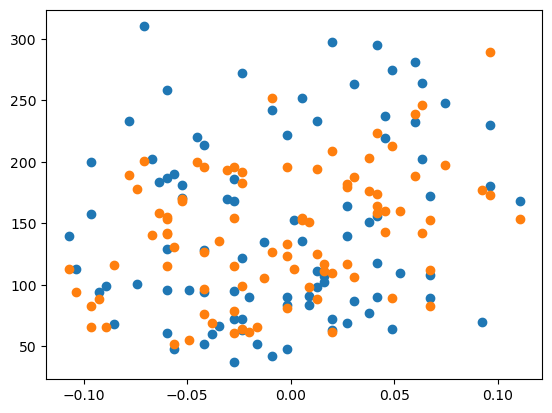

In [12]:
import matplotlib.pyplot as plt  ## ---- 수직 그래프에서 비슷한 분포도로 바뀌었다.
                                ### MSE 5000대 에서 2800대로 내려와서 제법 비슷해진거 같다.
plt.scatter(X_test[:, 0], y_test)
plt.scatter(X_test[:, 0], prediction)
plt.show()

print("프로젝트 1 완료.")

print("프로젝트 2 시작.")

## 프로젝트2 : 날씨 좋은 월요일 오후 세 시, 자전거 타는 사람은 몇 명?
캐글 경진대회 데이터를 사용해서 자전거 사용자 수를 예측하는 모델 훈련시키고 예측하기.

In [13]:
import pandas as pd   ### 자전거 데이터 가져오기 (딕셔너리랑 비슷한 데이터형)
### 경로 확인 잘 하기!
tf= pd.read_csv("~/data/data/bike-sharing-demand/train.csv") 
tf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [14]:
### 시간 계절 쉬는날 안빨간날 날씨 온도 체감온도 습도 풍속 자전거대여서비스 등록여부 총 렌탈횟수 12개의 특성이 있다.
#Data Fields
# datetime - hourly date + timestamp  
# season -  1 = spring, 2 = summer, 3 = fall, 4 = winter 
# holiday - whether the day is considered a holiday
# workingday - whether the day is neither a weekend nor holiday
# weather - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
# 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
# 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
# 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog 
# temp - temperature in Celsius
# atemp - "feels like" temperature in Celsius
# humidity - relative humidity
# windspeed - wind speed
# casual - number of non-registered user rentals initiated
# registered - number of registered user rentals initiated
# count - number of total rentals

In [15]:
tf['datetime'] = pd.to_datetime(tf['datetime']) ### dt. 날짜구성요소 추출
tf['year'] = tf['datetime'].dt.year
tf['month'] = tf['datetime'].dt.month
tf['day'] = tf['datetime'].dt.day
tf['hour'] = tf['datetime'].dt.hour
tf['minute'] = tf['datetime'].dt.minute
tf['second'] = tf['datetime'].dt.second

tf.info()  ## datatime이 객체에서 datetime64로 바뀌고 새로운 특성인 년도, 월, 일, 시, 분 ,초 가 추출되었다.
tf.head()
tf.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
 16  minute      10886 non-

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,minute,second
count,10886,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.0,10886.0
mean,2011-12-27 05:56:22.399411968,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132,2011.501929,6.521495,9.992559,11.541613,0.0,0.0
min,2011-01-01 00:00:00,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000,2011.000000,1.000000,1.000000,0.000000,0.0,0.0
25%,2011-07-02 07:15:00,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000,2011.000000,4.000000,5.000000,6.000000,0.0,0.0
50%,2012-01-01 20:30:00,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000,2012.000000,7.000000,10.000000,12.000000,0.0,0.0
75%,2012-07-01 12:45:00,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000,2012.000000,10.000000,15.000000,18.000000,0.0,0.0
max,2012-12-19 23:00:00,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000,2012.000000,12.000000,19.000000,23.000000,0.0,0.0
std,NaN,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454,0.500019,3.444373,5.476608,6.915838,0.0,0.0


info,head,describle()를 사용해서 데이터 살펴보기.
실수형 데이터들은 nomalization 하기.
범주형 자료들은 온-힛 코딩.

In [16]:
features = ['holiday','workingday','season', 'weather', 'temp', 'atemp' , 'humidity', 'windspeed','year', 'month', 'day', 'hour']
X = tf[features]
y = tf['count']

from sklearn.model_selection import train_test_split ##늘 먹던 훈련데이터와 테스트데이터 나누기. 익숙한 맛.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.preprocessing import MinMaxScaler
num_cols = ['temp', 'atemp', 'windspeed', 'humidity']
scaler = MinMaxScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

In [18]:
X_train[num_cols].describe().loc[['min','max']]

,temp,atemp,windspeed,humidity
min,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0


In [19]:
cat_cols = ['season',  'weather'] ## 범주형 자료는 온핫 코딩
X_train = pd.get_dummies(X_train, columns=cat_cols)
X_test  = pd.get_dummies(X_test,  columns=cat_cols)

In [20]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [21]:
set(X_train.columns) - set(X_test.columns)

set()

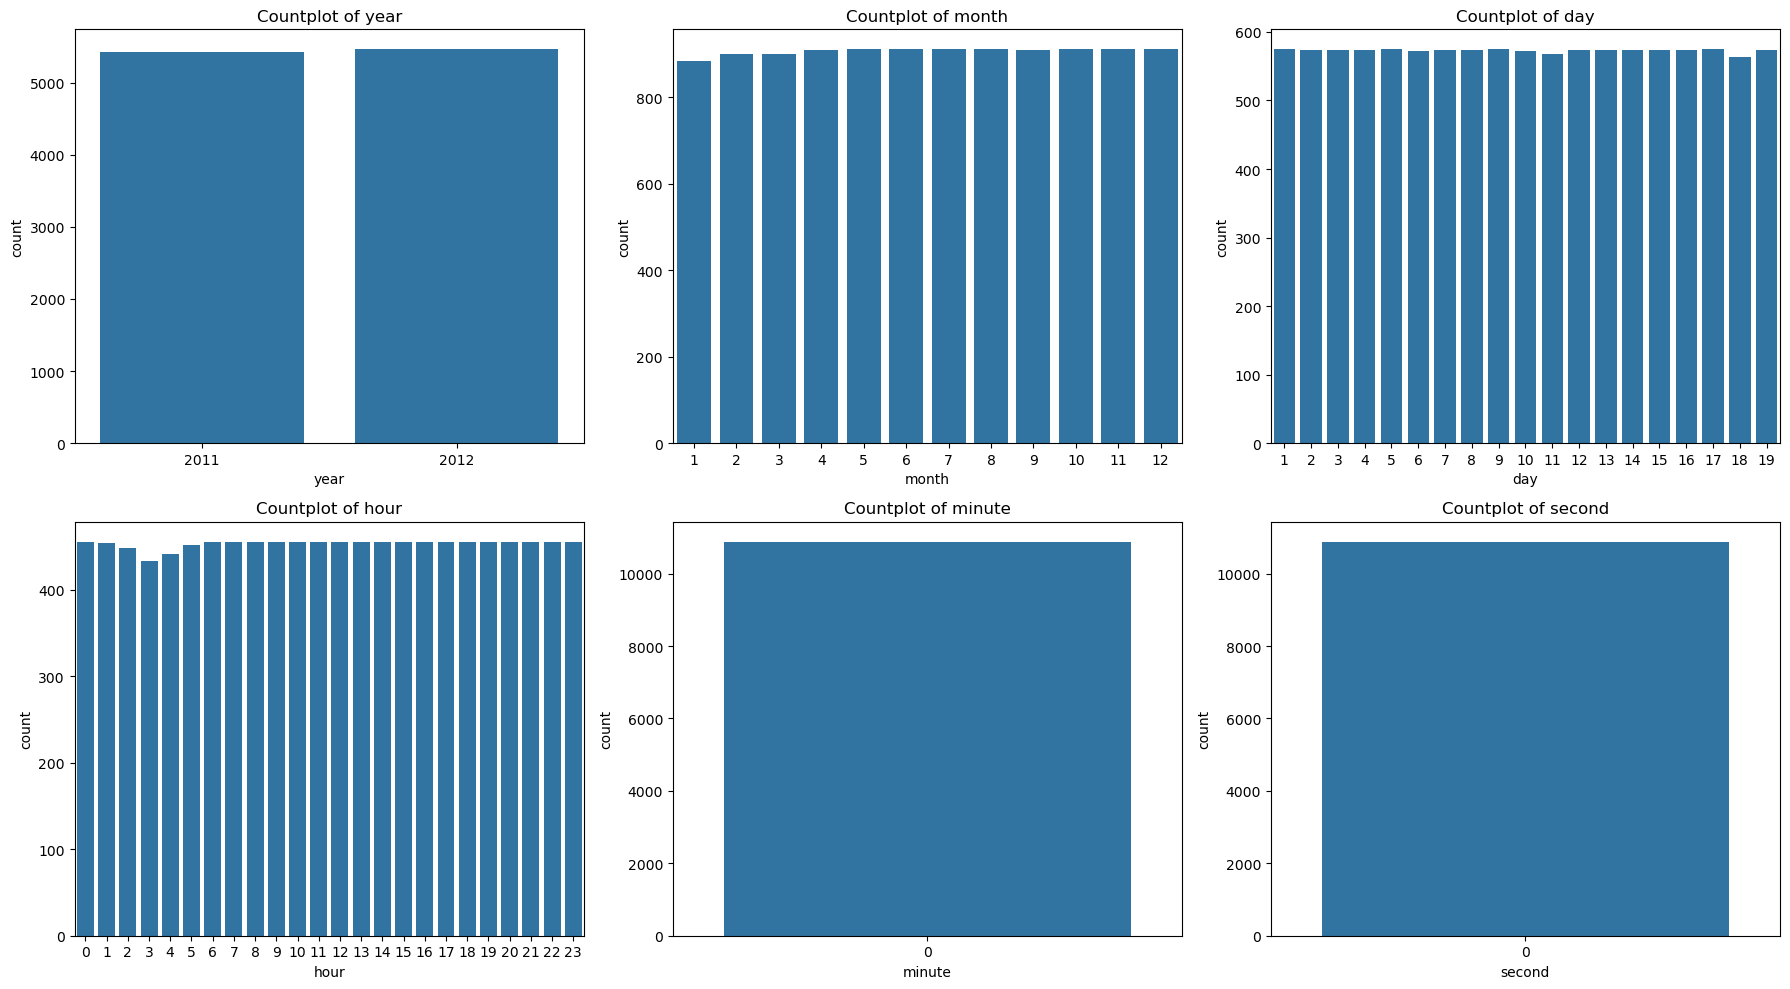

In [22]:
import matplotlib.pyplot as plt  ### 데이터 시각화
import seaborn as sns

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
cols = ['year', 'month', 'day', 'hour', 'minute', 'second']
for ax, col in zip(axs.flatten(), cols):
    sns.countplot(x=col, data=tf, ax=ax)
    ax.set_title(f'Countplot of {col}')
plt.tight_layout()
plt.show()

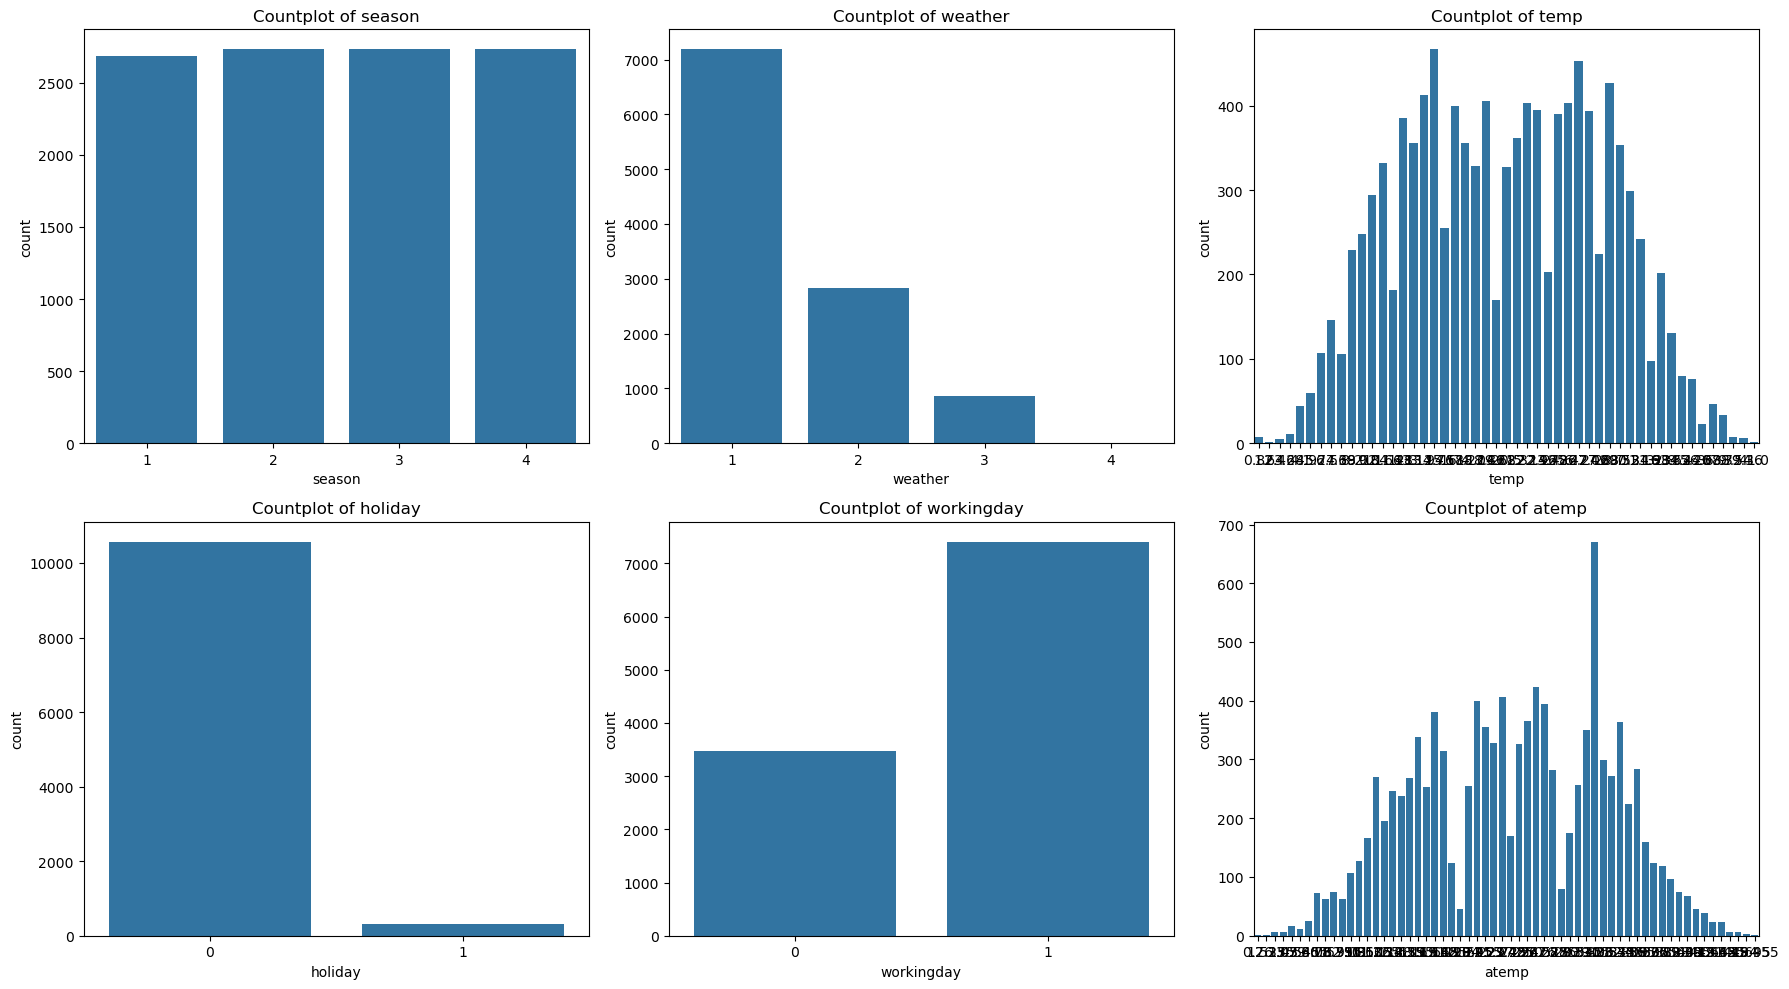

In [23]:
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
cols = ['season','weather','temp','holiday','workingday','atemp']
for ax, col in zip(axs.flatten(), cols):
    sns.countplot(x=col, data=tf, ax=ax)
    ax.set_title(f'Countplot of {col}')
plt.tight_layout()
plt.show()

분,초 는 중요해 보이지 않다.  
대여 서비스 등록자와 비등록자는 중요도가 떨어져 보인다.  
야외활동이기 때문에 계절 날씨 온도 시간대 습도 풍속이 중요해 보인다.  
중요한 특성만 데이터 컬럼에 넣기

In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()  ###sklrean 선형 회귀 모델로 아주 빠르게 학습
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
from sklearn.metrics import mean_squared_error 
import numpy as np
### sklearn 메트릭으로 아주 빠르게 손실함수 평가
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

MSE: 19784.29515511769
RMSE: 140.65665698827655


RMSE 140 나왔다. 에러를 줄이기 위해 자료를 시각화 해보자.

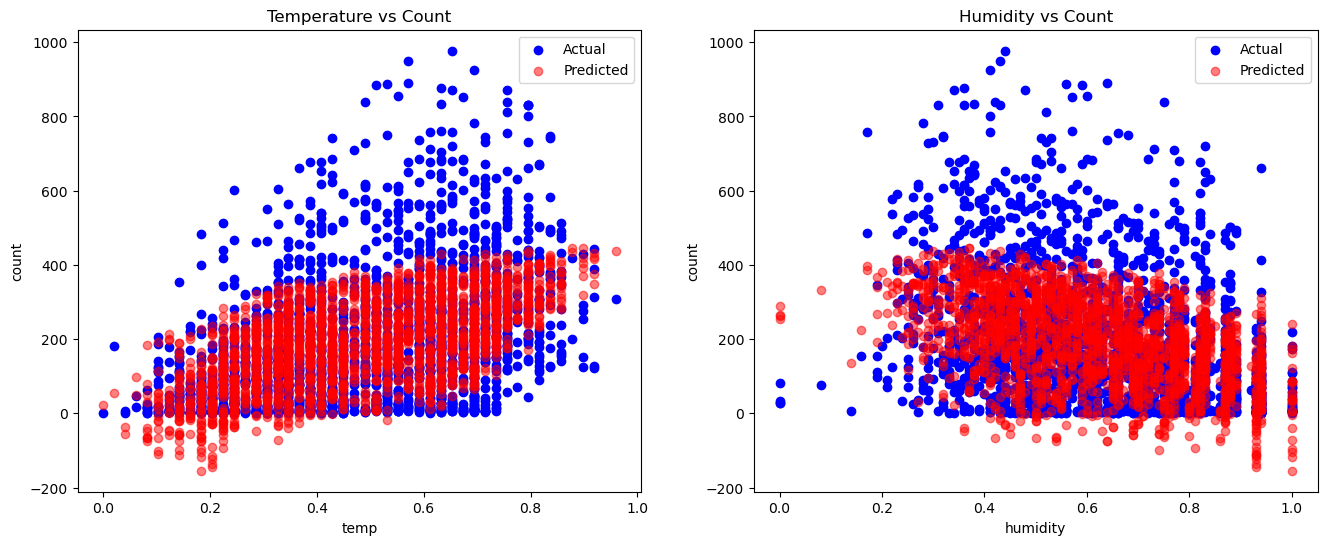

In [26]:
### 시각화
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# temp vs count 시각화
axs[0].scatter(X_test['temp'], y_test, color='blue', label='Actual')
axs[0].scatter(X_test['temp'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[0].set_xlabel('temp')
axs[0].set_ylabel('count')
axs[0].set_title('Temperature vs Count')
axs[0].legend()

# humidity vs count 시각화
axs[1].scatter(X_test['humidity'], y_test, color='blue', label='Actual')
axs[1].scatter(X_test['humidity'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[1].set_xlabel('humidity')
axs[1].set_ylabel('count')
axs[1].set_title('Humidity vs Count')
axs[1].legend()

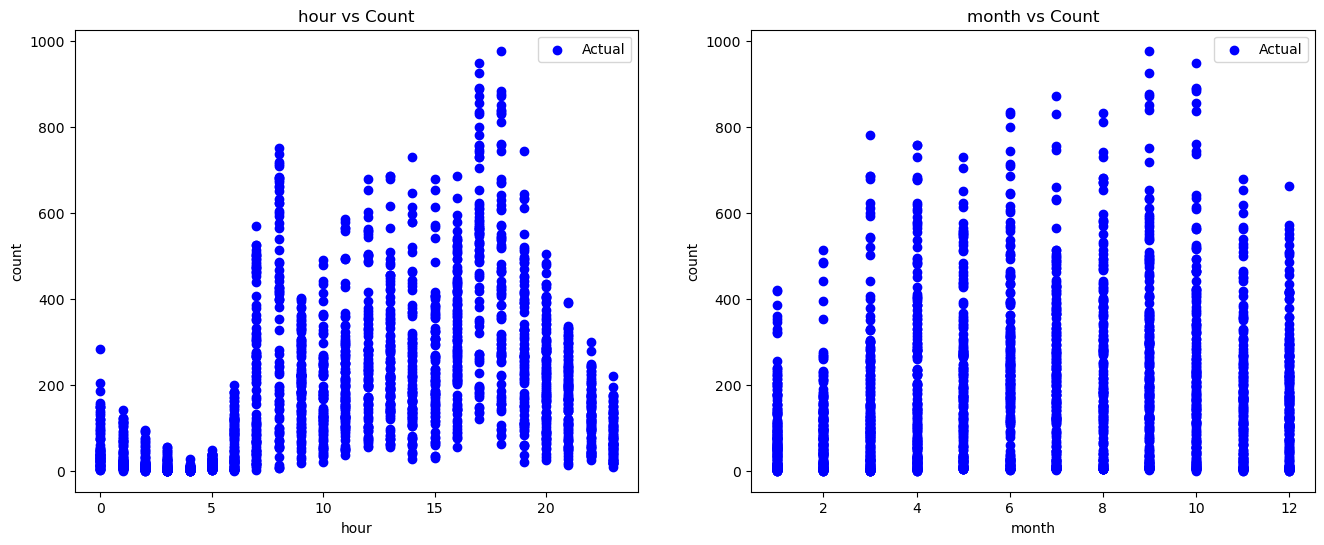

In [27]:
### 시각화
fig, axs = plt.subplots(1, 2, figsize=(16, 6))


axs[0].scatter(X_test['hour'], y_test, color='blue', label='Actual')
axs[0].set_xlabel('hour')
axs[0].set_ylabel('count')
axs[0].set_title('hour vs Count')
axs[0].legend()


axs[1].scatter(X_test['month'], y_test, color='blue', label='Actual')
axs[1].set_xlabel('month')
axs[1].set_ylabel('count')
axs[1].set_title('month vs Count')
axs[1].legend()

 ### 시간대 특성이 제일 중요하다. 
 - 온도와 습도에는 분명 상관관계가 있는것 같다.  
 - 활동하기 좋은 시간대에 대여횟수가 높게 형성된다  
 - 여가시간과 출퇴근시간에 자전거를 많이 탄다.

대여서비스 시간대를 구간화해보자.

In [28]:
bins = [-1, 6, 9, 16, 19, 23]
labels = ['Dawn', 'Rush_Morning', 'Daytime', 'Rush_Evening', 'Night']

X_train['time_bin'] = pd.cut(X_train['hour'], bins=bins, labels=labels)
X_test['time_bin'] = pd.cut(X_test['hour'], bins=bins, labels=labels)

X_train = pd.get_dummies(X_train, columns=['time_bin'], prefix='time_bin')
X_test = pd.get_dummies(X_test, columns=['time_bin'], prefix='time_bin')

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [29]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

MSE: 12277.606628397862
RMSE: 110.80436195564623


### 개선이 있었다!
 - 대여횟수 분포는 편중되어 있다.
 - 그렇다면 로그함수를 써서 분포를 정규화 해보자.

In [31]:
import numpy as np
# y_train을 로그 변환
y_train_log = np.log1p(y_train)
model.fit(X_train, y_train_log)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
###로그로그로그로그로그로그로그로그
y_pred_log = model.predict(X_test)
####역돌격실시! 안하면 260으로 껑충 뛴다구~
y_pred = np.expm1(y_pred_log)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)


MSE: 11179.392240353789
RMSE: 105.73264510241758


마지막 개선 년도 데이터를 온핫 코딩.

In [33]:
X_train['year'] = X_train['year'].astype(str)
X_test['year'] = X_test['year'].astype(str)

X_train = pd.get_dummies(X_train, columns=['year'], prefix='year')
X_test = pd.get_dummies(X_test, columns=['year'], prefix='year')

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [34]:
model.fit(X_train, np.log1p(y_train))

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
y_pred = np.expm1(model.predict(X_test))

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("복구된 MSE:", mse)
print("복구된 RMSE:", rmse)

복구된 MSE: 11179.39224035465
복구된 RMSE: 105.73264510242166


In [36]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8708 entries, 2815 to 7270
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   holiday                8708 non-null   int64  
 1   workingday             8708 non-null   int64  
 2   temp                   8708 non-null   float64
 3   atemp                  8708 non-null   float64
 4   humidity               8708 non-null   float64
 5   windspeed              8708 non-null   float64
 6   month                  8708 non-null   int32  
 7   day                    8708 non-null   int32  
 8   hour                   8708 non-null   int32  
 9   season_1               8708 non-null   bool   
 10  season_2               8708 non-null   bool   
 11  season_3               8708 non-null   bool   
 12  season_4               8708 non-null   bool   
 13  weather_1              8708 non-null   bool   
 14  weather_2              8708 non-null   bool   
 15  weathe

### 가장 중요한 특성은 뭘까?
RandomForestRegressor로 파악해보기

In [37]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,    # 트리 개수 (많을수록 안정적, 느림)
    max_depth=10,        # 트리 최대 깊이 (깊을수록 과적합 위험)
    random_state=42
)

model.fit(X_train, y_train)

import pandas as pd

current_features = X_train.columns


importance_df = pd.DataFrame({
    '피처': current_features,
    '중요도': model.feature_importances_
}).sort_values('중요도', ascending=False)


print(importance_df.head(23))

                       피처       중요도
8                    hour  0.305688
17          time_bin_Dawn  0.159529
20  time_bin_Rush_Evening  0.112637
1              workingday  0.094019
6                   month  0.054945
2                    temp  0.053917
22              year_2011  0.048416
23              year_2012  0.044693
3                   atemp  0.035268
19       time_bin_Daytime  0.029310
4                humidity  0.020063
15              weather_3  0.013800
9                season_1  0.010825
7                     day  0.006241
5               windspeed  0.003965
18  time_bin_Rush_Morning  0.001578
0                 holiday  0.001352
12               season_4  0.000982
13              weather_1  0.000863
21         time_bin_Night  0.000670
10               season_2  0.000542
11               season_3  0.000392
14              weather_2  0.000306


In [39]:
model.fit(X_train, np.log1p(y_train))

y_pred_log = model.predict(X_test)

y_pred = np.expm1(y_pred_log)

final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"RMSE: {final_rmse}")

RMSE: 58.80510825558477


In [45]:
# y_train 그대로 vs log1p 적용 후 비교
model_log = RandomForestRegressor(n_estimators=100, random_state=42)
model_log.fit(X_train, np.log1p(y_train))
pred_log = np.expm1(model_log.predict(X_test))

model_raw = RandomForestRegressor(n_estimators=100, random_state=42)
model_raw.fit(X_train, y_train)
pred_raw = model_raw.predict(X_test)

print(f'로그 변환 RMSE: {np.sqrt(mean_squared_error(y_test, pred_log)):.2f}')
print(f'변환 없음 RMSE: {np.sqrt(mean_squared_error(y_test, pred_raw)):.2f}')

로그 변환 RMSE: 43.93
변환 없음 RMSE: 42.17


선형회귀모델과 다르게 RandomForestRegressor는 로그변화 효과가 미비했다.  
그리고 데이터를 비선형적관계로 분석하여 분포보단 토큰화시킨 특성들이 더 중요해보인다.